# PCA — redukcja wymiarów: kompletne rozwiązanie

**Blok III · wersja prowadzącego · wszystkie komórki uruchomione**

Zadania wykonano na wbudowanym zbiorze Wine: 13 cech, trzy klasy. W rozwiązaniu skalowanie i PCA są uczone wyłącznie na treningu. Zapisane wyniki pochodzą z podziału `random_state=42`.


### 0. Przygotowanie danych

Ta komórka jest kompletna. Uruchom ją przed rozwiązywaniem zadań.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

data = load_wine(as_frame=True)
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print(X_train.shape, X_test.shape, 'klasy:', sorted(y.unique()))
display(X_train.head())

(133, 13) (45, 13) klasy: [np.int64(0), np.int64(1), np.int64(2)]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
8,14.83,1.64,2.17,14.0,97.0,2.8,2.98,0.29,1.98,5.20,1.08,2.85,1045.0
104,12.51,1.73,1.98,20.5,85.0,2.2,1.92,0.32,1.48,2.94,1.04,3.57,672.0
36,13.28,1.64,2.84,15.5,110.0,2.6,2.68,0.34,1.36,4.60,1.09,2.78,880.0
78,12.33,0.99,1.95,14.8,136.0,1.9,1.85,0.35,2.76,3.40,1.06,2.31,750.0
2,13.16,2.36,2.67,18.6,101.0,2.8,3.24,0.30,2.81,5.68,1.03,3.17,1185.0


### Zadanie 1. Skalowanie i składowe

Dopasuj `StandardScaler` wyłącznie na treningu, a następnie PCA z `n_components=2`. Przekształć trening i test tymi samymi obiektami. Wypisz `explained_variance_ratio_` oraz sumę udziałów.

In [2]:
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
pca = PCA(n_components=2).fit(X_train_scaled)
X_train_2d = pca.transform(X_train_scaled)
X_test_2d = pca.transform(X_test_scaled)
variance_share = pca.explained_variance_ratio_.sum()
print('Udział składowych:', pca.explained_variance_ratio_.round(3))
print(f'Suma udziałów: {variance_share:.3f}')


Udział składowych: [0.357 0.192]
Suma udziałów: 0.550


**Odpowiedź — czy największa wariancja musi najlepiej rozdzielać klasy?** Nie. PCA wyznacza osie opisujące zmienność **cech `X`** i podczas dopasowania nie widzi etykiet `y`. Duża wariancja może wynikać z czynnika, który jest słabo związany z klasą. W tym uruchomieniu PC1 wyjaśnia około 35,7%, PC2 około 19,2%, razem około **55,0% wariancji cech**. To nie jest miara skuteczności klasyfikacji.


### Zadanie 2. Mapa 2D

Narysuj scatter dwóch składowych dla **treningu**, kolorując punkty według klasy. Dodaj podpisy osi i legendę lub colorbar.

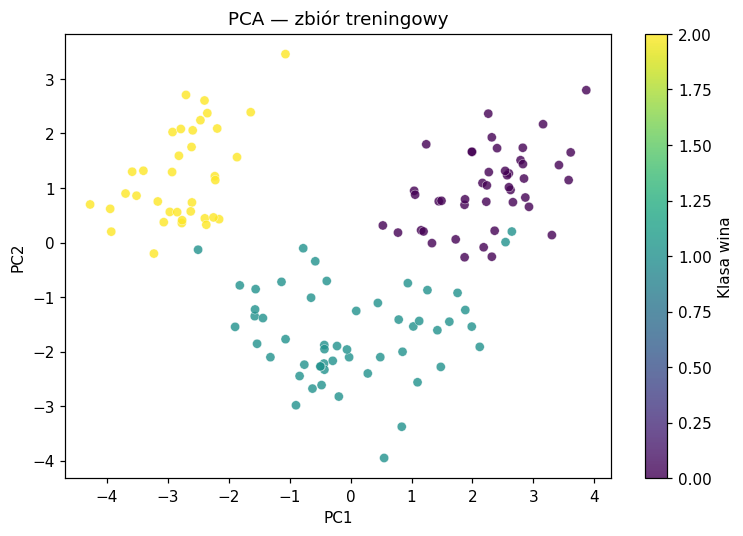

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train,
                     cmap='viridis', alpha=0.8, edgecolors='white', linewidths=0.3)
ax.set(xlabel='PC1', ylabel='PC2', title='PCA — zbiór treningowy')
fig.colorbar(scatter, ax=ax, label='Klasa wina')
plt.tight_layout()
plt.show()


**Odpowiedź — które klasy są rozdzielone?** Na projekcji treningu klasa **0** skupia się głównie po prawej, klasa **2** po lewej u góry, a klasa **1** niżej, bliżej środka. Obszary nie są idealnie rozdzielone: kilka punktów klasy 1 zbliża się do skupisk pozostałych klas. To obraz 2D, więc nie dowodzi, że te same punkty są nierozdzielne w pełnych 13 wymiarach.


### Zadanie 3. Ile składowych?

Na treningu dopasuj PCA zachowujące co najmniej 95% wariancji (`n_components=0.95`). Zapisz liczbę składowych w `n_95` i narysuj skumulowany udział wyjaśnionej wariancji.

Liczba składowych dla co najmniej 95% wariancji: 10


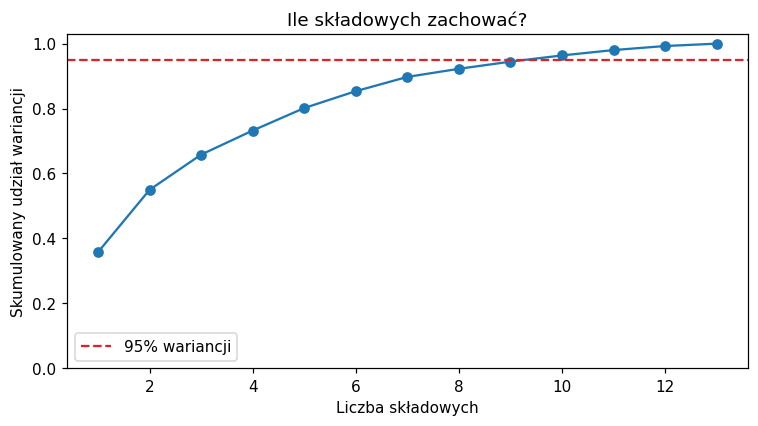

In [4]:
pca_95 = PCA(n_components=0.95).fit(X_train_scaled)
n_95 = pca_95.n_components_
pca_full = PCA().fit(X_train_scaled)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cumulative) + 1), cumulative, marker='o')
ax.axhline(0.95, color='tab:red', linestyle='--', label='95% wariancji')
ax.set(xlabel='Liczba składowych', ylabel='Skumulowany udział wariancji',
       title='Ile składowych zachować?', ylim=(0, 1.03))
ax.legend()
plt.tight_layout()
plt.show()
print('Liczba składowych dla co najmniej 95% wariancji:', n_95)


**Odpowiedź — co tracimy przy dwóch składowych?** Dwie pierwsze zachowują około **55,0% wariancji**, a więc pomijamy około **45,0% wariancji cech**. W tym podziale do zachowania co najmniej 95% potrzeba **10 składowych**. Utrata wariancji nie przekłada się automatycznie na taką samą utratę informacji o klasie: PCA nie wykorzystuje etykiet.


### Zadanie 4. Czy PCA pomaga klasyfikacji?

Porównaj dwie Pipeline na tym samym podziale: `StandardScaler → LogisticRegression(max_iter=2000)` oraz `StandardScaler → PCA(n_components=2) → LogisticRegression(max_iter=2000)`. Oceń accuracy na teście.

In [5]:
full_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
pca_model = make_pipeline(StandardScaler(), PCA(n_components=2),
                          LogisticRegression(max_iter=2000))
full_model.fit(X_train, y_train)
pca_model.fit(X_train, y_train)
acc_full = accuracy_score(y_test, full_model.predict(X_test))
acc_pca_2 = accuracy_score(y_test, pca_model.predict(X_test))
print(f'Bez PCA: accuracy={acc_full:.3f}')
print(f'Z PCA(2): accuracy={acc_pca_2:.3f}')


Bez PCA: accuracy=1.000
Z PCA(2): accuracy=0.911


**Odpowiedź — dlaczego większa wariancja nie musi oznaczać wyższej accuracy?** Model ze wszystkimi cechami uzyskał na odłożonym teście **1,000 (45/45 poprawnych)**, a model z dwoma składowymi **0,911 (41/45 poprawnych)**. Kierunki, które PCA odrzuciło, mogły zawierać informacje użyteczne do rozróżniania klas mimo mniejszej wariancji. To wynik jednego niewielkiego testu; nie stanowi dowodu, że PCA zawsze pogarsza klasyfikację. W obu Pipeline scaler i ewentualne PCA uczą się tylko na treningu.


---
**Dokumentacja:** https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

**Wersja prowadzącego:** pełny kod, wykonane komórki, wykresy i odpowiedzi interpretacyjne.
